In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
import scanpy as sc
import torch
import scarches as sca
from scarches.dataset.trvae.data_handling import remove_sparsity
import matplotlib.pyplot as plt
import numpy as np
import gdown

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 captum (see https://github.com/pytorch/captum).


In [3]:
import pandas as pd

In [4]:
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

## load query

In [5]:
adata_query = sc.read_h5ad("Braga_asthma_lung_celltypist.h5ad")

In [6]:
adata_query

AnnData object with n_obs × n_vars = 96803 × 27468
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden'
    var: 'n_counts', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'leiden', 'leiden_sizes', 'log1p', 'main_predicted_cell_groups_colors', 'majority_voting_colors', 'neighbors', 'paga', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [7]:
adata_query.obs.main_predicted_cell_groups.unique()[:10]

['Multiciliated (non-nasal)', 'Basal resting', 'Suprabasal', 'EC venous systemic', 'Goblet (nasal)', 'Classical monocytes', 'Club (non-nasal)', 'Mast cells', 'CD4 T cells', 'DC2']
Categories (26, object): ['Alveolar macrophages', 'B cells', 'Basal resting', 'CD4 T cells', ..., 'SMG mucous', 'SMG serous (bronchial)', 'Smooth muscle', 'Suprabasal']

In [8]:
adata_query.obs.main_predicted_cell_groups.unique()[10:20]

['SMG mucous', 'CD8 T cells', 'Peribronchial fibroblasts', 'Non-classical monocytes', 'SMG duct', 'SMG serous (bronchial)', 'Alveolar macrophages', 'EC arterial', 'Ionocyte', 'NK cells']
Categories (26, object): ['Alveolar macrophages', 'B cells', 'Basal resting', 'CD4 T cells', ..., 'SMG mucous', 'SMG serous (bronchial)', 'Smooth muscle', 'Suprabasal']

In [9]:
adata_query.obs.main_predicted_cell_groups.unique()[20:]

['Smooth muscle', 'B cells', 'Plasmacytoid DCs', 'Plasma cells', 'Lymphatic EC mature', 'Goblet (bronchial)']
Categories (26, object): ['Alveolar macrophages', 'B cells', 'Basal resting', 'CD4 T cells', ..., 'SMG mucous', 'SMG serous (bronchial)', 'Smooth muscle', 'Suprabasal']

In [10]:
adata_query.obs.main_predicted_cell_groups.value_counts()

Multiciliated (non-nasal)    33032
Suprabasal                   22014
Basal resting                12363
CD8 T cells                   7264
CD4 T cells                   4595
Club (non-nasal)              4052
EC venous systemic            3208
DC2                           1700
Classical monocytes           1671
Peribronchial fibroblasts     1182
B cells                        802
Mast cells                     793
Plasma cells                   558
Goblet (bronchial)             508
Goblet (nasal)                 465
Smooth muscle                  415
NK cells                       371
SMG duct                       313
Ionocyte                       279
SMG serous (bronchial)         270
Non-classical monocytes        240
EC arterial                    224
SMG mucous                     184
Alveolar macrophages           133
Plasmacytoid DCs               126
Lymphatic EC mature             41
Name: main_predicted_cell_groups, dtype: int64

In [32]:
adata_query = adata_query[adata_query.obs.main_predicted_cell_groups.isin(['Classical monocytes', 'Mast cells', 'CD4 T cells', 
                                                           'DC2', 'CD8 T cells', 'Non-classical monocytes', 'NK cells', 
                                                           'B cells', 'Alveolar macrophages', 'Plasmacytoid DCs', 'Plasma cells'])].copy()

In [33]:
adata_query

AnnData object with n_obs × n_vars = 18253 × 27468
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden'
    var: 'n_counts', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'leiden', 'leiden_sizes', 'log1p', 'main_predicted_cell_groups_colors', 'majority_voting_colors', 'neighbors', 'paga', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [ ]:
sc.pl.umap(
    adata_query,
    color=["main_predicted_cell_groups", "majority_voting"],
    frameon=False,
    size=6,
    ncols=2,
    #legend_loc="on data"
)

## load reference

In [34]:
adata_ref = sc.read_h5ad("Myeloid_B_T_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad")

In [35]:
commonGen = [gen for gen in adata_query.var_names if gen in adata_ref.var_names]

In [36]:
commonGen[:10]

['AP006222.2',
 'FAM87B',
 'LINC00115',
 'SAMD11',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'HES4',
 'ISG15',
 'AGRN']

In [37]:
adata_ref = adata_ref[:, commonGen]

In [38]:
adata_ref

View of AnnData object with n_obs × n_vars = 365203 × 16528
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_c

In [40]:
sc.pp.highly_variable_genes(
    adata_ref,
    n_top_genes=2000,
    batch_key="dataset_id",
    subset=True)

In [42]:
adata_ref.X = adata_ref.raw[:, adata_ref.var_names].X

In [43]:
adata_query = adata_query[:, adata_ref.var_names]

In [44]:
adata_ref

AnnData object with n_obs × n_vars = 365203 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_cells_by_c

## SCVI model

In [60]:
sca.models.SCVI.setup_anndata(adata_ref,  batch_key="donor_id", labels_key="Cell_type_scANVI")

In [61]:
vae = sca.models.SCVI(
    adata_ref,
    n_layers=3,
    encode_covariates=True,
    deeply_inject_covariates=False,
    use_layer_norm="both",
    use_batch_norm="none",
)

In [52]:
early_stopping_kwargs = {
    #"early_stopping_metric": "elbo",
    "save_best_state_metric": "elbo",
    "patience": 10,
    "threshold": 0,
    "reduce_lr_on_plateau": True,
    "lr_patience": 8,
    "lr_factor": 0.1,
}
vae.train()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 22/22: 100%|██████████| 22/22 [12:39<00:00, 34.25s/it, v_num=1, train_loss_step=473, train_loss_epoch=483]

INFO: `Trainer.fit` stopped: `max_epochs=22` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=22` reached.


Epoch 22/22: 100%|██████████| 22/22 [12:39<00:00, 34.51s/it, v_num=1, train_loss_step=473, train_loss_epoch=483]


In [62]:
scanvae = sca.models.SCANVI.from_scvi_model(vae, unlabeled_category = "Unknown")

In [63]:
print("Labelled Indices: ", len(scanvae._labeled_indices))
print("Unlabelled Indices: ", len(scanvae._unlabeled_indices))

Labelled Indices:  365203
Unlabelled Indices:  0


In [64]:
scanvae.train()

INFO     Training for 7 epochs.                                                                                    


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 7/7: 100%|██████████| 7/7 [09:55<00:00, 84.39s/it, v_num=1, train_loss_step=480, train_loss_epoch=516]

INFO: `Trainer.fit` stopped: `max_epochs=7` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.


Epoch 7/7: 100%|██████████| 7/7 [09:55<00:00, 85.10s/it, v_num=1, train_loss_step=480, train_loss_epoch=516]


In [66]:
reference_latent = sc.AnnData(scanvae.get_latent_representation())
reference_latent.obs["Cell_type_scANVI"] = adata_ref.obs["Cell_type_scANVI"].tolist()
reference_latent.obs["dataset_id"] = adata_ref.obs["Cell_type_scANVI"].tolist()


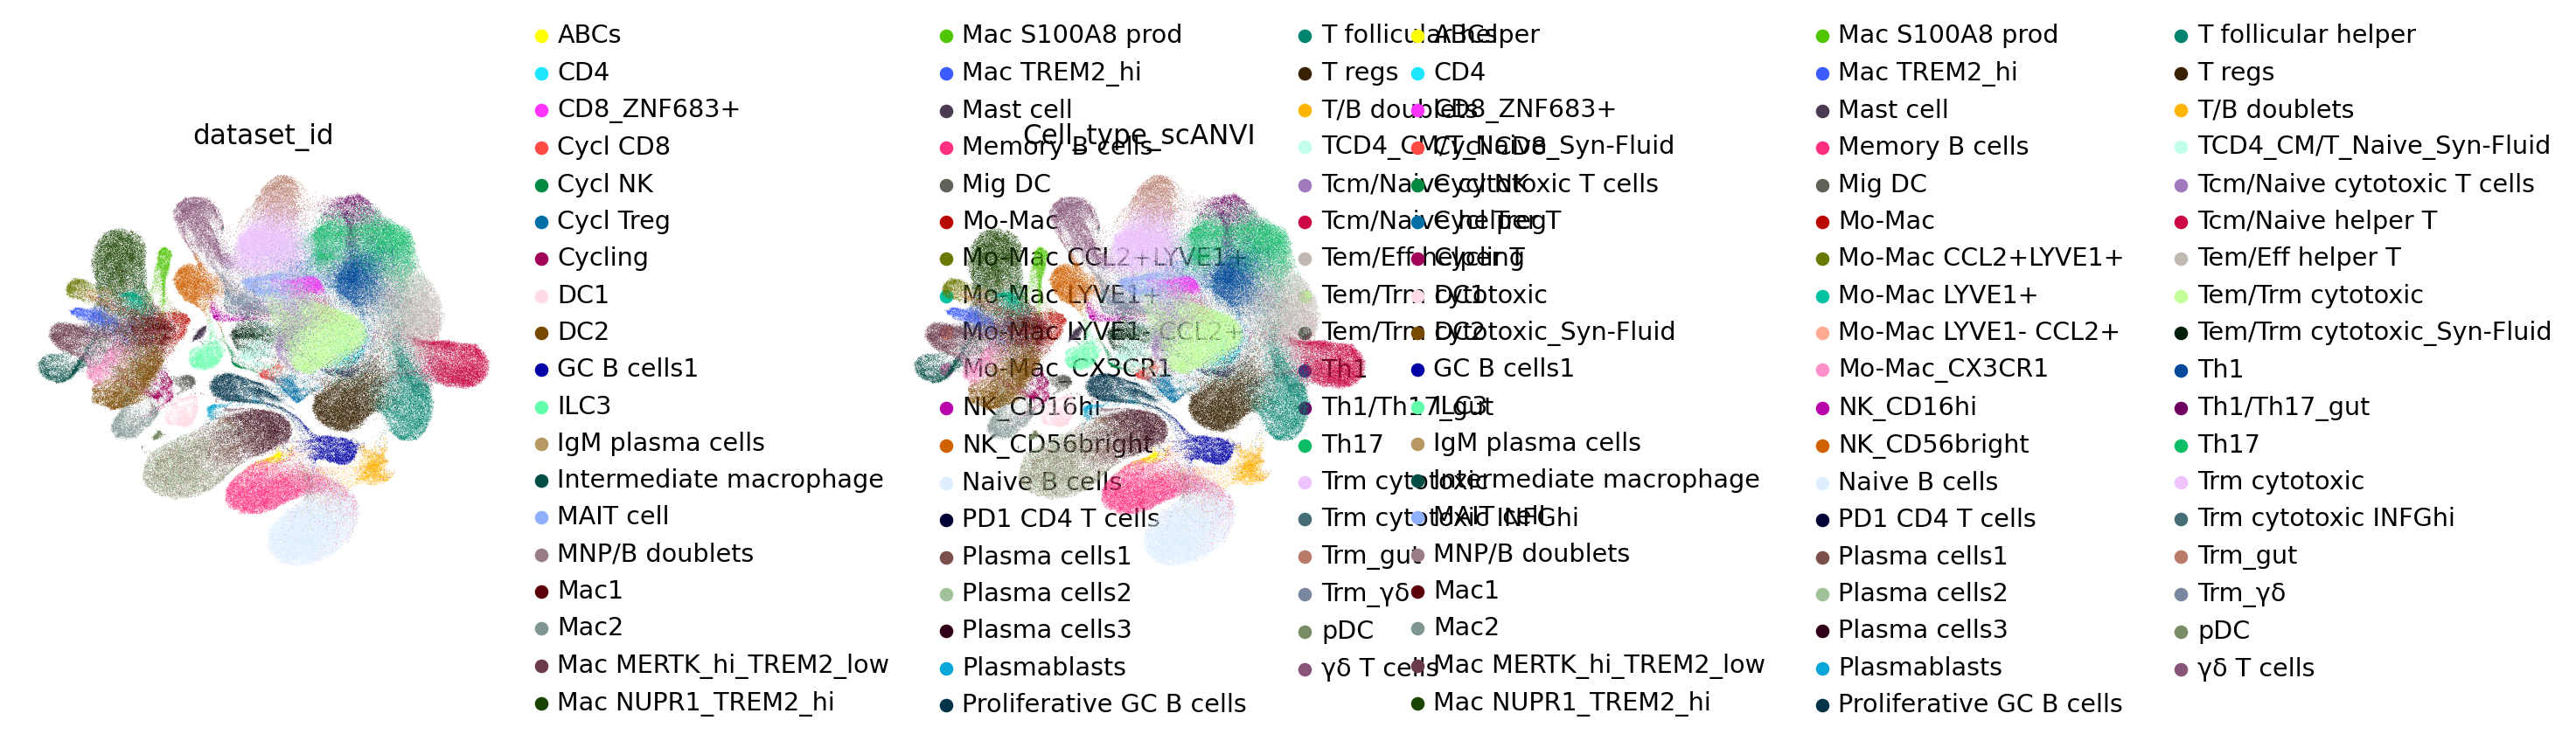

In [67]:
sc.pp.neighbors(reference_latent, n_neighbors=8)
sc.tl.leiden(reference_latent)
sc.tl.umap(reference_latent)
sc.pl.umap(reference_latent,
           color=['dataset_id', 'Cell_type_scANVI'],
           frameon=False,
           wspace=0.6,
           )

In [68]:
reference_latent.obs['predictions'] = scanvae.predict()
print("Acc: {}".format(np.mean(reference_latent.obs.predictions == reference_latent.obs.Cell_type_scANVI)))

Acc: 0.8351464801767784


In [69]:
ref_path = 'ref_model_tissue/'
scanvae.save(ref_path, overwrite=True)

## Surgery with the query dataset

In [70]:
adata_query = adata_query.copy()

In [71]:
model = sca.models.SCANVI.load_query_data(
    adata_query,
    ref_path,
    freeze_dropout = True,
)
model._unlabeled_indices = np.arange(adata_query.n_obs)
model._labeled_indices = []
print("Labelled Indices: ", len(model._labeled_indices))
print("Unlabelled Indices: ", len(model._unlabeled_indices))

INFO     File ref_model_tissue/model.pt already downloaded                                                         
Labelled Indices:  0
Unlabelled Indices:  18253


In [72]:
model.train(
    max_epochs=50,
    plan_kwargs=dict(weight_decay=0.0),
    check_val_every_n_epoch=10,
)

INFO     Training for 50 epochs.                                                                                   


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 50/50: 100%|██████████| 50/50 [02:31<00:00,  3.15s/it, v_num=1, train_loss_step=612, train_loss_epoch=610]

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [02:31<00:00,  3.04s/it, v_num=1, train_loss_step=612, train_loss_epoch=610]


In [73]:
query_latent = sc.AnnData(model.get_latent_representation())
query_latent.obs['Cell_type_scANVI'] = adata_query.obs['Cell_type_scANVI'].tolist()
query_latent.obs['dataset_id'] = adata_query.obs['dataset_id'].tolist()

<Figure size 320x320 with 0 Axes>

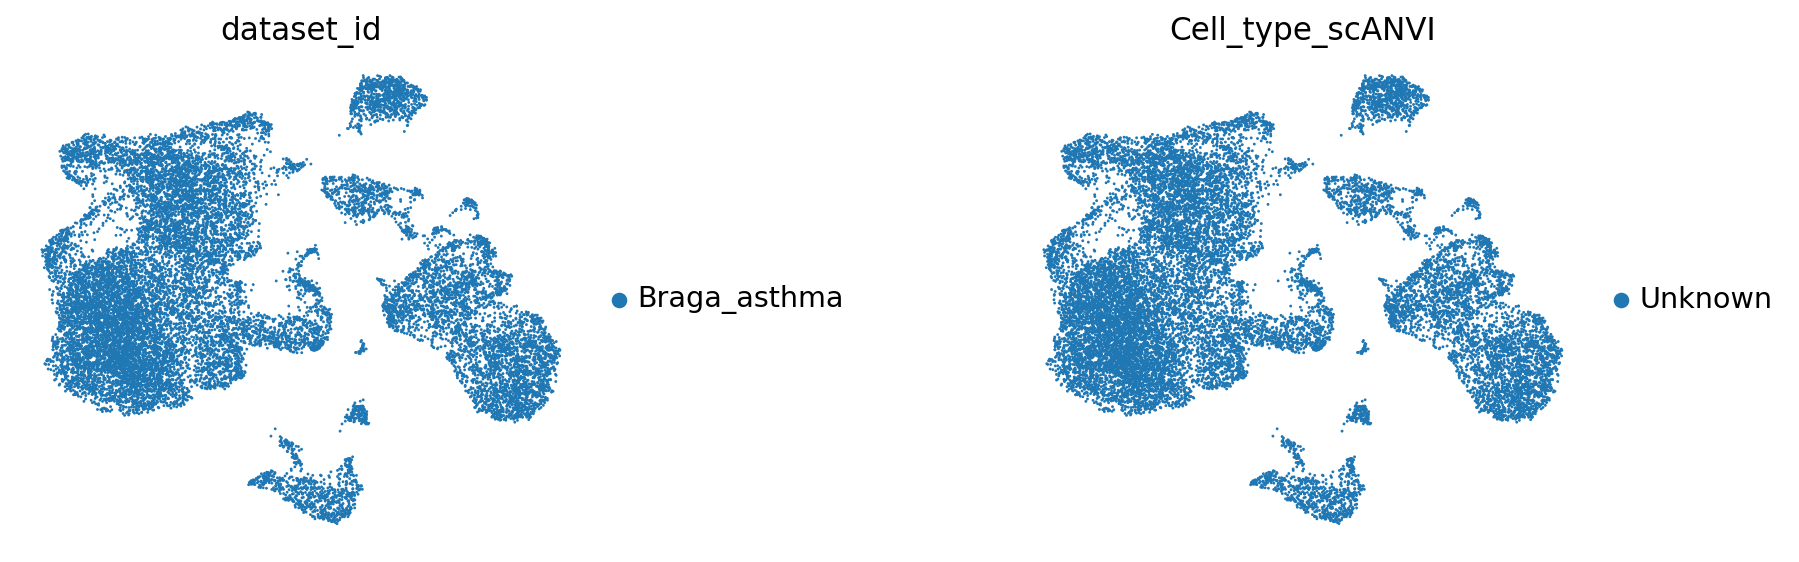

In [74]:
sc.pp.neighbors(query_latent)
sc.tl.leiden(query_latent)
sc.tl.umap(query_latent)
plt.figure()
sc.pl.umap(
    query_latent,
    color=["dataset_id", "Cell_type_scANVI"],
    frameon=False,
    wspace=0.6,
)

In [75]:
surgery_path = 'surgery_model_tissue'
model.save(surgery_path, overwrite=True)

## Latent representation of reference + query dataset and compute UMAP

In [76]:
adata_full = adata_ref.concatenate(adata_query, batch_key="ref_query")
adata_full

AnnData object with n_obs × n_vars = 383456 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'main_predicted_cell_groups', 'leiden', 'ref_query'
    var: 'mt-0-0', 'rb-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts

In [77]:
full_latent = sc.AnnData(model.get_latent_representation(adata=adata_full))
full_latent.obs['Cell_type_scANVI'] = adata_full.obs["Cell_type_scANVI"].tolist()
full_latent.obs['donor_id'] = adata_full.obs['donor_id'].tolist()

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [78]:
full_latent.obs['dataset_id'] = adata_full.obs['dataset_id'].tolist()

<Figure size 320x320 with 0 Axes>

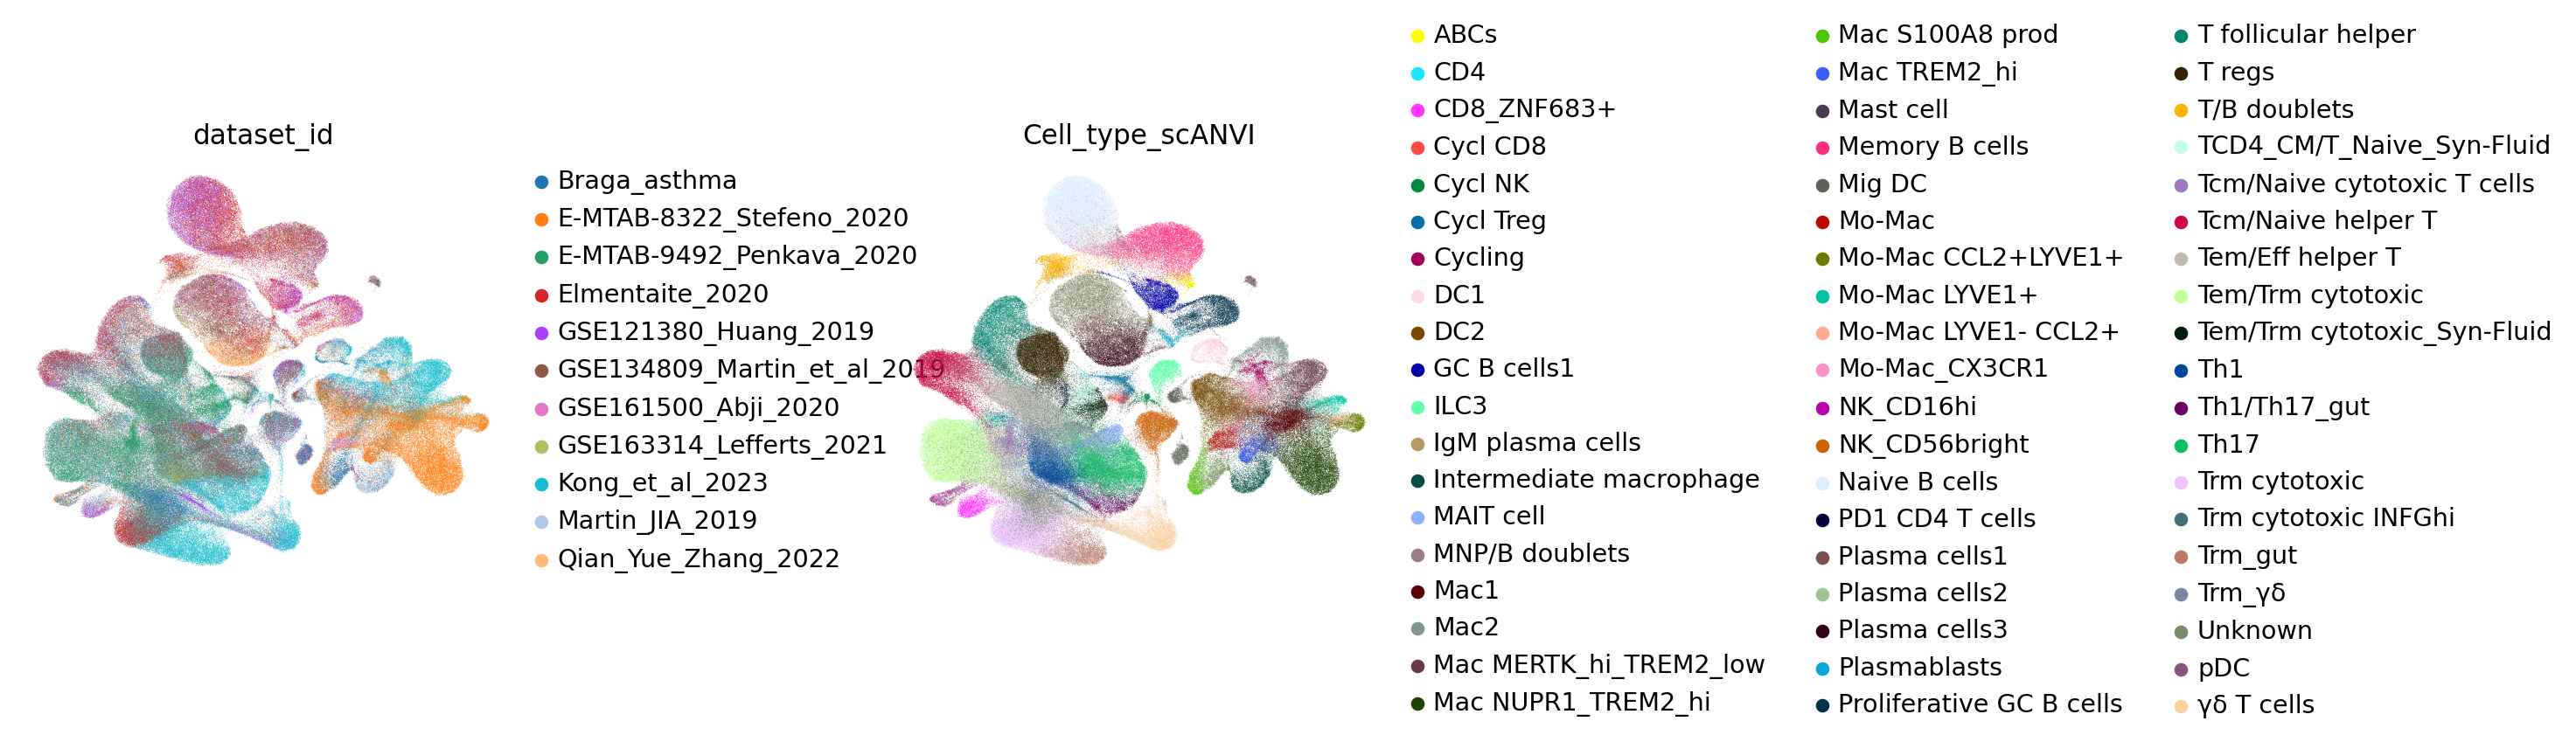

In [79]:

sc.pp.neighbors(full_latent)
sc.tl.leiden(full_latent)
sc.tl.umap(full_latent)
plt.figure()
sc.pl.umap(
    full_latent,
    color=["dataset_id", "Cell_type_scANVI"],
    frameon=False,
    wspace=0.6,
)

In [80]:
full_latent.obs['predictions'] = model.predict(adata=adata_full)

<Figure size 320x320 with 0 Axes>

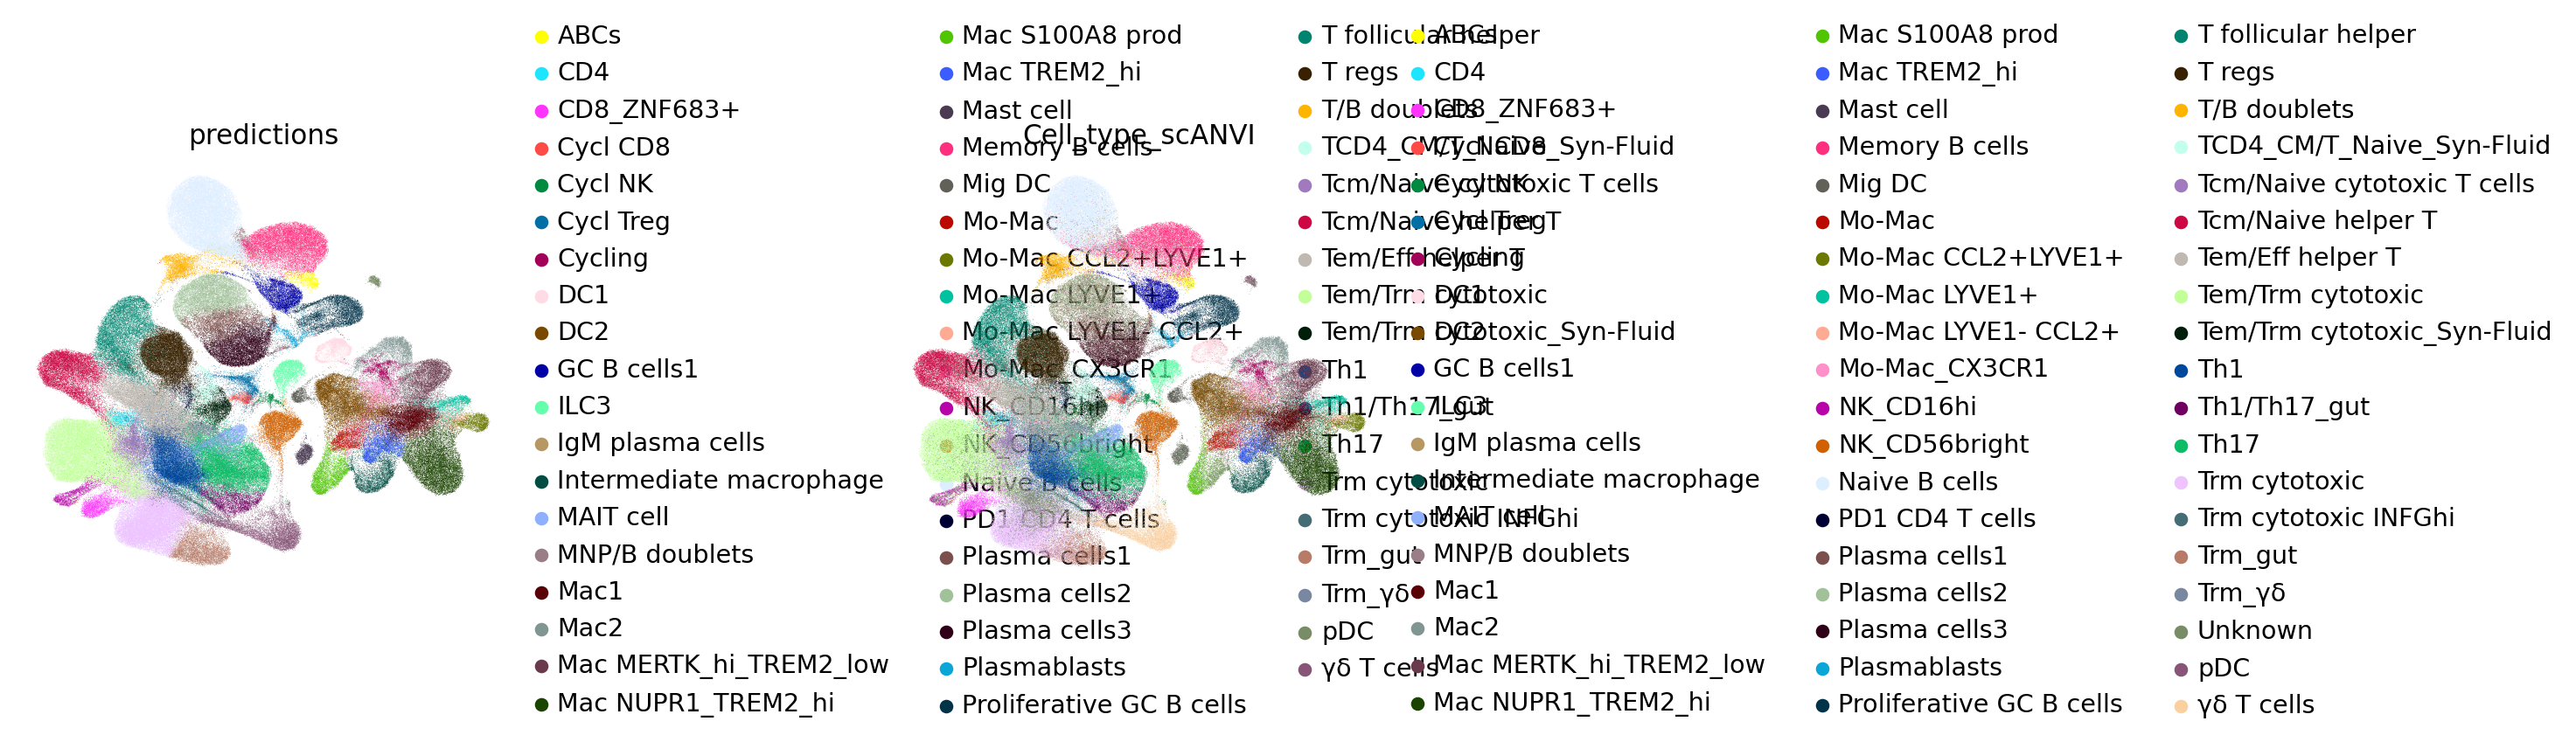

In [81]:
sc.pp.neighbors(full_latent)
sc.tl.leiden(full_latent)
sc.tl.umap(full_latent)
plt.figure()
sc.pl.umap(
    full_latent,
    color=["predictions", "Cell_type_scANVI"],
    frameon=False,
    wspace=0.6,
)

In [82]:
full_latent

AnnData object with n_obs × n_vars = 383456 × 10
    obs: 'Cell_type_scANVI', 'donor_id', 'dataset_id', 'leiden', 'predictions'
    uns: 'neighbors', 'leiden', 'umap', 'dataset_id_colors', 'Cell_type_scANVI_colors', 'predictions_colors'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

In [85]:
full_latent[full_latent.obs.Cell_type_scANVI != "Cell_type_scANVI"].obs["predictions"].value_counts()

Tem/Trm cytotoxic              28339
Trm cytotoxic                  25697
Naive B cells                  23227
Th17                           20589
Tem/Eff helper T               19350
Th1                            17014
T regs                         16338
Memory B cells                 13977
T follicular helper            13388
Mac NUPR1_TREM2_hi             12585
Tcm/Naive helper T             12369
DC2                            11576
Plasma cells2                  10688
Plasma cells3                  10569
γδ T cells                      8704
Mac1                            7629
Mac MERTK_hi_TREM2_low          7104
NK_CD56bright                   6751
Trm_gut                         6733
Proliferative GC B cells        6663
MAIT cell                       6151
Plasma cells1                   5798
Tcm/Naive cytotoxic T cells     5207
Mac2                            5182
GC B cells1                     4975
Th1/Th17_gut                    4621
Intermediate macrophage         4611
M

In [88]:
adata_query.obs.disease.value_counts()

Asthma    18253
Name: disease, dtype: int64

In [90]:
adata_query.obs

,dataset_id,donor_id,tissue,cell_source,disease,disease_status,age,sex,developmental_stage,sample_id,...,n_genes,predicted_labels,over_clustering,majority_voting,conf_score,main_predicted_cell_groups,leiden,_scvi_batch,_scvi_labels,Cell_type_scANVI
AAAGTAGTCTACCTGC-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAAGTAGTCTACCTGC,...,1980,Classical monocytes,40,Classical monocytes,0.633904,Classical monocytes,13,220,56,Unknown
AAATGCCAGGCAGTCA-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAATGCCAGGCAGTCA,...,2173,Classical monocytes,40,Classical monocytes,0.453228,Classical monocytes,13,220,56,Unknown
AACTCTTCACTCGACG-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AACTCTTCACTCGACG,...,579,Mast cells,25,Mast cells,0.992807,Mast cells,20,220,56,Unknown
AACTCTTCAGTCGATT-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AACTCTTCAGTCGATT,...,1476,CD8 T cells,128,CD4 T cells,0.081286,CD4 T cells,7,220,56,Unknown
AAGACCTTCCGTTGCT-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAGACCTTCCGTTGCT,...,1694,Classical monocytes,40,Classical monocytes,0.785995,Classical monocytes,13,220,56,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAAGGATATAC-1-1-1-1-1-1-1-1-1-1-1,Braga_asthma,CTTV027_RNAseq6949177,lung,NaN,Asthma,NaN,NaN,NaN,NaN,TTTGTCAAGGATATAC,...,1291,CD8 T cells,66,CD8 T cells,0.466035,CD8 T cells,7,218,56,Unknown
TTTGTCAAGTGCCAGA-1-1-1-1-1-1-1-1-1-1-1,Braga_asthma,CTTV027_RNAseq6949177,lung,NaN,Asthma,NaN,NaN,NaN,NaN,TTTGTCAAGTGCCAGA,...,1291,Non-classical monocytes,198,Non-classical monocytes,0.987867,Non-classical monocytes,13,218,56,Unknown
TTTGTCACACCTCGTT-1-1-1-1-1-1-1-1-1-1-1,Braga_asthma,CTTV027_RNAseq6949177,lung,NaN,Asthma,NaN,NaN,NaN,NaN,TTTGTCACACCTCGTT,...,1274,Classical monocytes,40,Classical monocytes,0.598630,Classical monocytes,13,218,56,Unknown
TTTGTCACAGGACCCT-1-1-1-1-1-1-1-1-1-1-1,Braga_asthma,CTTV027_RNAseq6949177,lung,NaN,Asthma,NaN,NaN,NaN,NaN,TTTGTCACAGGACCCT,...,772,CD8 T cells,1,CD8 T cells,0.696028,CD8 T cells,10,218,56,Unknown


In [101]:
adata_full.obs.disease_tissue.value_counts()

Paed_IBD_colon                  23299
hashimoto_thyroid               20035
Paed_IBD_ileum                  10720
CD_ileum                         9474
Uninfl_CD_ileum                  7345
Paed_Healthy_ileum               7334
CD_spondyloarthritis_colon        932
Healthy_colon                     818
CD_colon                          778
Resitant_treat_RA_syno_membr      691
spondyloarhtriti_colon            553
Remission_RA_syno_membr           232
Naïve_treat_RA_syno_membr         123
Name: disease_tissue, dtype: int64

In [153]:
#correct disease

sample = {"CTTV027_RNAseq6949177":"Healthy", 
          "CTTV027_RNAseq7487979":"Asthma", 
          "CTTV027_RNAseq7333559":"Asthma", 
          "4951STDY7487591":"Healthy",
          "CTTV027_RNAseq7118946":"Healthy", 
          "CTTV027_RNAseq7333558":"Asthma", 
          "CTTV027_RNAseq6949176":"Healthy", 
          "CTTV027_RNAseq7118945":"Healthy", 
          "CTTV027_RNAseq7333557":"Healthy", 
          "CTTV027_RNAseq6949175":"Asthma", 
          "CTTV027_RNAseq7018935":"Asthma", 
          "CTTV027_RNAseq7018936":"Asthma"}

In [154]:
adata_ref.obs.disease_tissue.value_counts()

Paed_IBD_colon                  23299
hashimoto_thyroid               20035
Paed_IBD_ileum                  10720
CD_ileum                         9474
Uninfl_CD_ileum                  7345
Paed_Healthy_ileum               7334
CD_spondyloarthritis_colon        932
Healthy_colon                     818
CD_colon                          778
Resitant_treat_RA_syno_membr      691
spondyloarhtriti_colon            553
Remission_RA_syno_membr           232
Naïve_treat_RA_syno_membr         123
Name: disease_tissue, dtype: int64

In [100]:
adata_query.obs["tissue_harmo"] = "Lung"

In [155]:
adata_query.obs['disease'] = adata_query.obs.donor_id

In [156]:
adata_query.obs['disease'] = (
    adata_query.obs["disease"]
    .map(lambda x: sample.get(x, x))
    .astype("category")
)

In [157]:
adata_query.obs['disease'].value_counts()

Healthy    10114
Asthma      8139
Name: disease, dtype: int64

In [158]:
adata_query

AnnData object with n_obs × n_vars = 18253 × 2000
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden', '_scvi_batch', '_scvi_labels', 'Cell_type_scANVI', 'tissue_harmo', 'disease_tissue'
    var: 'n_counts', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'leiden', 'leiden_sizes', 'log1p', 'main_predicted_cell_groups_colors', 'majority_voting_colors', 'neighbors', 'paga', 'pca', 'umap', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [159]:
adata_ref

AnnData object with n_obs × n_vars = 365203 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_cells_by_c

In [160]:
adata_full = adata_ref.concatenate(adata_query, batch_key="ref_query")
adata_full

AnnData object with n_obs × n_vars = 383456 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'main_predicted_cell_groups', 'leiden', 'ref_query'
    var: 'mt-0-0', 'rb-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts

In [161]:
adata_full.obs["disease_label_trans"] = adata_full.obs.disease.astype("str") + "_" + adata_full.obs.tissue_harmo.astype("str")

In [162]:
adata_full.obs['disease_label_trans'].value_counts(dropna = False)

Uninflam_CD_Ileum                               74829
Psoriatic arthritis_Synovial fluid              40392
Paediatric IBD_Colon                            37406
Crohn's Disease_Ileum                           35742
Hashimoto’s thyroiditis_Thyroid                 33413
Rheumatoid Arthritis_Synovial membrane          29631
Paediatric IBD_Ileum                            20097
Oligoarticular JIA_Synovial fluid               18862
Uninflam_CD_Colon                               14000
Healthy_Colon                                   13835
Paed_Healthy_Ileum                              13266
Healthy_Lung                                    10114
Crohn's Disease_Colon                            9917
Asthma_Lung                                      8139
Undifferentiated Arthritis_Synovial membrane     6910
Healthy_Ileum                                    6837
Healthy_Synovial membrane                        5032
Spondyloarhtritis_Colon                          2445
CD + Spondyloarthritis_Colon

In [163]:
adata_full.obs['disease'].value_counts(dropna = False)

Uninflam_CD                   88829
Paediatric IBD                57503
Crohn's Disease               45659
Psoriatic arthritis           41043
Healthy                       35818
Hashimoto’s thyroiditis       33413
Rheumatoid Arthritis          29631
Oligoarticular JIA            18862
Paed_Healthy                  13266
Asthma                         8139
Undifferentiated Arthritis     6910
Spondyloarhtritis              2445
CD + Spondyloarthritis         1938
Name: disease, dtype: int64

In [165]:
adata_full.obs['predictions'] = model.predict(adata=adata_full)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [166]:
adata_full.obs[['disease_label_trans', 'predictions']].value_counts()

disease_label_trans                 predictions      
Uninflam_CD_Ileum                   Trm cytotoxic        10577
Paediatric IBD_Colon                Naive B cells        10512
Psoriatic arthritis_Synovial fluid  Tem/Trm cytotoxic    10320
                                    Tem/Eff helper T      8840
Uninflam_CD_Ileum                   Th17                  8578
                                                         ...  
CD + Spondyloarthritis_Colon        ILC3                     1
Paediatric IBD_Ileum                DC1                      1
Oligoarticular JIA_Synovial fluid   Trm_gut                  1
Paediatric IBD_Ileum                Trm_gut                  1
                                    Mig DC                   1
Length: 885, dtype: int64

In [167]:
adata_full.obs.dataset_id.value_counts()

Kong_et_al_2023                101054
GSE134809_Martin_et_al_2019     47390
E-MTAB-8322_Stefeno_2020        41573
E-MTAB-9492_Penkava_2020        38906
GSE121380_Huang_2019            37406
Elmentaite_2020                 34902
Qian_Yue_Zhang_2022             33413
Martin_JIA_2019                 18862
Braga_asthma                    18253
GSE163314_Lefferts_2021          9560
GSE161500_Abji_2020              2137
Name: dataset_id, dtype: int64

In [168]:
adata_full.obs.Cell_type_scANVI.value_counts()

Tem/Trm cytotoxic              25831
Trm cytotoxic                  24807
Naive B cells                  21693
Th17                           19936
Tem/Eff helper T               19195
Unknown                        18253
T regs                         15089
Memory B cells                 14690
Th1                            14476
Tcm/Naive helper T             13136
T follicular helper            13106
Mac NUPR1_TREM2_hi             13065
DC2                            10791
Plasma cells1                   9885
Plasma cells2                   9014
γδ T cells                      8625
Mac1                            7422
Plasma cells3                   6881
Mac MERTK_hi_TREM2_low          6789
NK_CD56bright                   6394
Proliferative GC B cells        6391
Trm_gut                         5944
MAIT cell                       5659
GC B cells1                     5140
Mac2                            4848
Trm_γδ                          4631
Tcm/Naive cytotoxic T cells     4539
T

In [178]:
pd.DataFrame(adata_full.obs).to_csv("Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu.csv")

In [179]:
!rclone copy Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu.csv\
'gdrive:Projects/SCVI_Results/Milo_combine/'

In [180]:
!rclone copy surgery_model_tissue/\
'gdrive:Projects/SCVI_Results/Milo_combine/surgery_model_tissue/'

<Figure size 320x320 with 0 Axes>

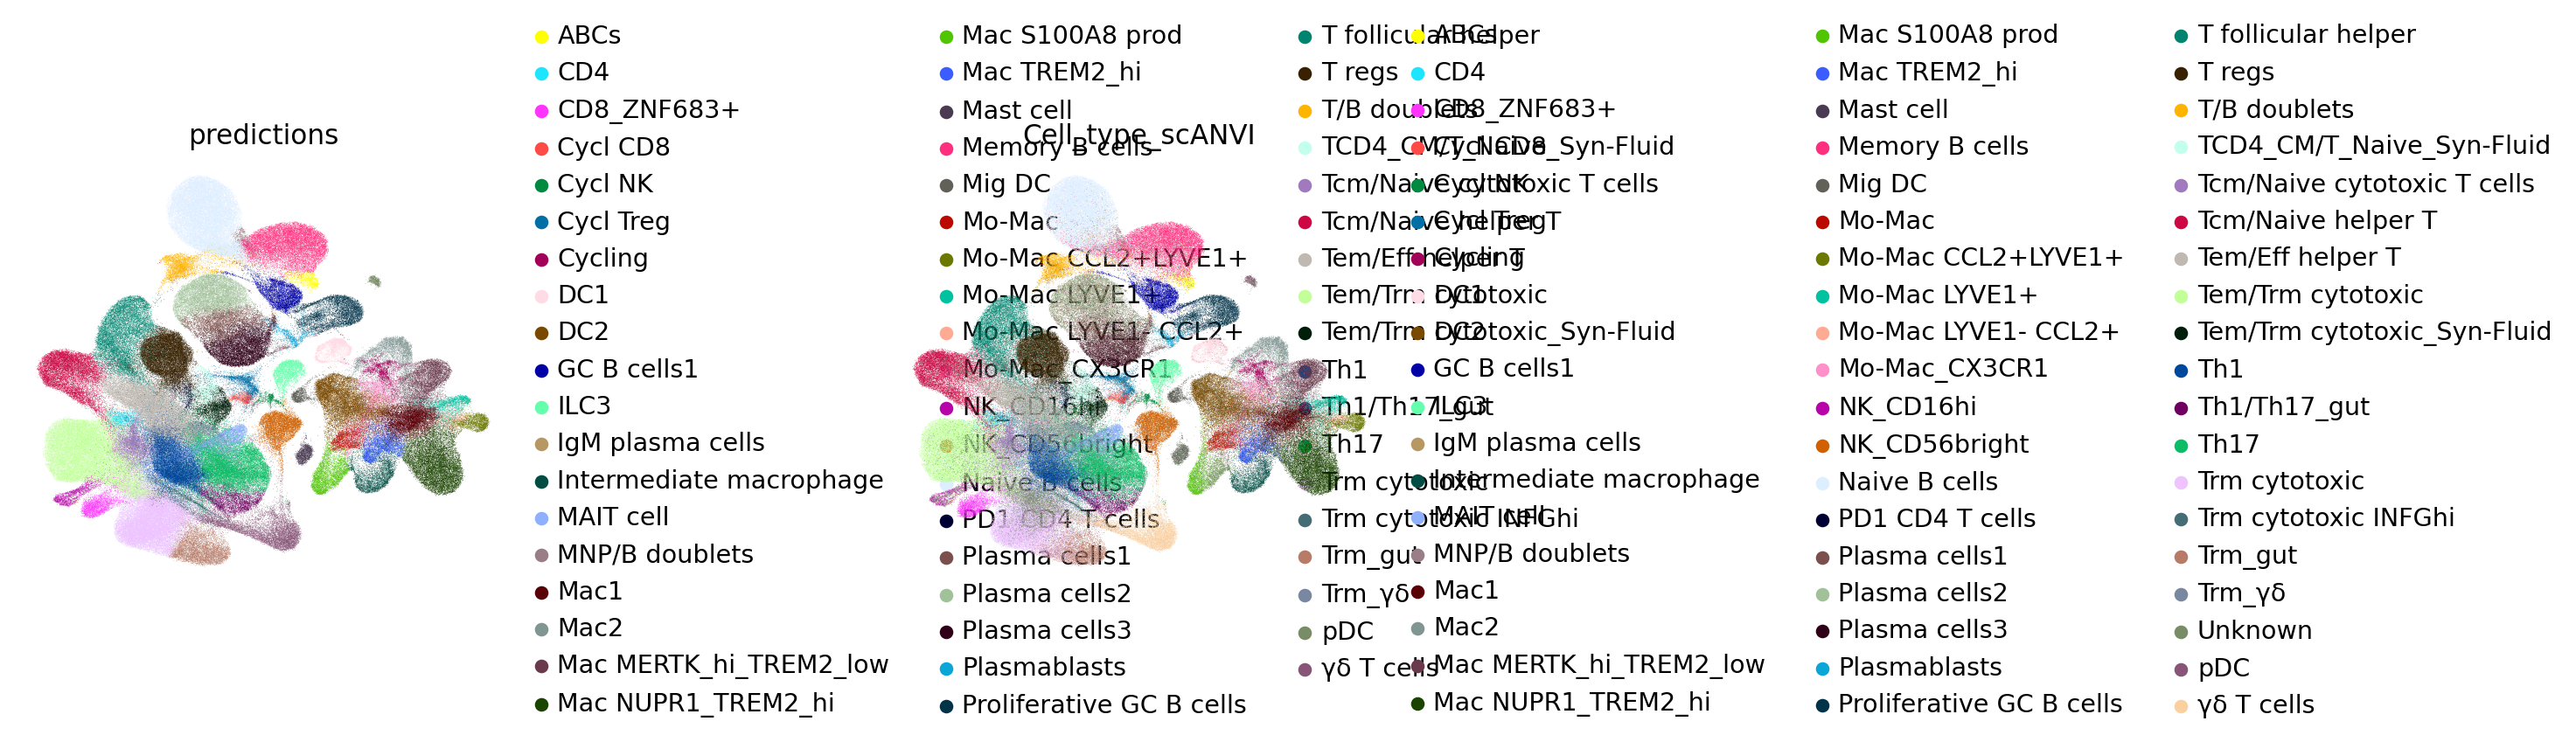

In [81]:
sc.pp.neighbors(full_latent)
sc.tl.leiden(full_latent)
sc.tl.umap(full_latent)
plt.figure()
sc.pl.umap(
    full_latent,
    color=["predictions", "Cell_type_scANVI"],
    frameon=False,
    wspace=0.6,
)